# Casting defects - the classifier, and whether it reproduces

**Arkon Manufacturing AI | Module: CV Binary | Department: Foundry**

ResNet-18 with ImageNet weights, the whole network fine-tuned, six epochs, and
the epoch with the best validation PR AUC kept. That is the configuration the
metrics file records and the model card quotes, and the model behind the risk
events the Quality Steering Cell receives.

This notebook writes the experiment out again and runs it. Nothing is imported
from the training script and no checkpoint is loaded anywhere, so agreement with
the metrics file is a reproduction rather than a restatement.

## 1. Imports and configuration

The shared helpers live in `notebooks/utils`. This cell puts that directory on the path.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import get_mlflow_uri, save_figure

print('arkon_utils loaded')

arkon_utils loaded


The libraries and the shipped experiment, written out here rather than imported. The last line prints whether cuDNN is pinned to deterministic kernels, which section 11 needs.

In [2]:
import copy
import hashlib
import json
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights, resnet18

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

ASSETS = 'cv'
RAW_DIR = Path('../../../data/03_casting/raw')
PROC_DIR = Path('../../../data/03_casting/processed')
CKPT_DIR = Path('../../../models/checkpoints/casting')
META_PATH = CKPT_DIR / 'casting_cv_meta.json'

# The shipped experiment, written out rather than imported.
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 6
LEARNING_RATE = 1e-4
VALIDATION_FRACTION = 0.15
# None of these ratios ships with the dataset. They are an Arkon assumption about
# what a shipped defect costs against a re-inspected good part.
COST_RATIOS = [10, 25, 50]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'python  {sys.version.split()[0]}')
print(f'torch   {torch.__version__}')
print(f'device  {DEVICE}' + (f'  {torch.cuda.get_device_name(0)}' if DEVICE.type == 'cuda' else ''))
print(f'cudnn deterministic {torch.backends.cudnn.deterministic}, '
      f'benchmark {torch.backends.cudnn.benchmark}')

python  3.12.10
torch   2.6.0+cu124
device  cuda  NVIDIA GeForce RTX 3070 Laptop GPU
cudnn deterministic False, benchmark False


## 2. The reference, read before anything is trained

Whatever the previous run recorded. It is loaded now, while it still describes
that run, and compared against in section 11. This notebook does not overwrite
it: section 10 writes its own artifacts under their own names.

In [3]:
reference = json.loads(META_PATH.read_text(encoding='utf-8'))
shipped = reference['operating_points']['missed_defect_costs_25x']

print('reference metrics found, written by the previous run')
print(f'  architecture        {reference["architecture"]}')
print(f'  {reference["epochs"]} epochs, best epoch {reference["best_epoch"]}, seed '
      f'{reference["seed"]}, batch {reference["batch_size"]}, image {reference["image_size"]}')
print(f'  operating point     threshold {shipped["threshold"]:.4f}, '
      f'{shipped["defects_missed"]} defects missed, '
      f'{shipped["good_parts_rejected"]} good parts rejected')
print(f'  at 0.5              {reference["at_threshold_0.5"]["defects_missed"]} missed, '
      f'{reference["at_threshold_0.5"]["good_parts_rejected"]} rejected, '
      f'ROC AUC {reference["at_threshold_0.5"]["roc_auc"]}')
print(f'  frozen ablation     recall '
      f'{reference["ablation_frozen_backbone"]["at_threshold_0.5"]["recall"]}, '
      f'{reference["ablation_frozen_backbone"]["at_threshold_0.5"]["defects_missed"]} missed')

reference metrics found, written by the previous run
  architecture        resnet18, ImageNet weights, whole network fine-tuned
  6 epochs, best epoch 2, seed 42, batch 32, image 224
  operating point     threshold 0.0637, 0 defects missed, 7 good parts rejected
  at 0.5              2 missed, 1 rejected, ROC AUC 0.9999
  frozen ablation     recall 0.9492, 23 missed


## 3. The data, the split and the loaders

Rebuilt here rather than read from notebook 02, so the agreement on the split is
reached twice independently. The training subset gets the augmenting transform
and the validation subset does not.

In [4]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def split_indices(targets, fraction, seed):
    """Stratified train and validation indices over a label array."""
    generator = np.random.default_rng(seed)
    train_index, validation_index = [], []
    for label in np.unique(targets):
        rows = np.where(targets == label)[0]
        generator.shuffle(rows)
        cut = int(round(len(rows) * fraction))
        validation_index.extend(rows[:cut].tolist())
        train_index.extend(rows[cut:].tolist())
    return sorted(train_index), sorted(validation_index)


def view(dataset, transform):
    """A shallow copy carrying its own transform, sharing the file list."""
    other = copy.copy(dataset)
    other.transform = transform
    return other


folder = ImageFolder(RAW_DIR / 'train')
test_set = ImageFolder(RAW_DIR / 'test', transform=EVAL_TRANSFORM)
DEFECT_INDEX = folder.class_to_idx['def_front']
targets = np.array(folder.targets)
train_index, validation_index = split_indices(targets, VALIDATION_FRACTION, SEED)

train_loader = DataLoader(Subset(view(folder, TRAIN_TRANSFORM), train_index),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                          pin_memory=DEVICE.type == 'cuda')
validation_loader = DataLoader(Subset(view(folder, EVAL_TRANSFORM), validation_index),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                               pin_memory=DEVICE.type == 'cuda')
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                         pin_memory=DEVICE.type == 'cuda')

print('classes', folder.class_to_idx, '| defect index', DEFECT_INDEX)
print(f'\n{"":<14}{"here":>8}{"recorded":>10}{"delta":>8}')
for name, mine, theirs in (('train', len(train_index), reference['train_images']),
                           ('validation', len(validation_index), reference['validation_images']),
                           ('test', len(test_set), reference['test_images'])):
    print(f'{name:<14}{mine:>8,}{theirs:>10,}{mine - theirs:>8}')

classes {'def_front': 0, 'ok_front': 1} | defect index 0

                  here  recorded   delta
train            5,638     5,638       0
validation         995       995       0
test               715       715       0


## 4. Which test images the model will have seen

The duplicates from notebook 01, recomputed here so this notebook does not depend
on that one having been run, and mapped onto the split above. The result is the
row mask section 8 uses.

In [5]:
def pixel_hash(path):
    with Image.open(path) as image:
        return hashlib.sha256(np.asarray(image.convert('L')).tobytes()).hexdigest()


t0 = time.time()
train_hashes = [pixel_hash(path) for path, _ in folder.samples]
test_hashes = [pixel_hash(path) for path, _ in test_set.samples]
fitted_hashes = {train_hashes[i] for i in train_index}
validation_hashes = {train_hashes[i] for i in validation_index}

seen_in_training = np.array([h in fitted_hashes for h in test_hashes])
seen_in_validation = np.array([h in validation_hashes for h in test_hashes])
unseen = ~(seen_in_training | seen_in_validation)

print(f'hashed {len(train_hashes) + len(test_hashes):,} images in {time.time() - t0:.1f}s\n')
print(f'{"test images fitted on":<38}{int(seen_in_training.sum()):>6}')
print(f'{"test images in the validation subset":<38}{int(seen_in_validation.sum()):>6}')
print(f'{"test images genuinely unseen":<38}{int(unseen.sum()):>6}')
print(f'{"test images in total":<38}{len(test_hashes):>6}')

hashed 7,348 images in 30.9s

test images fitted on                     55
test images in the validation subset       9
test images genuinely unseen             651
test images in total                     715


## 5. The model, and the training loop

`resnet18` with the ImageNet weights and a two-class head. Those weights are
torchvision's, not this project's earlier work, and a random initialisation would
train a different model whose disagreement would mean nothing. The loop keeps the
epoch with the best validation PR AUC rather than the last. This cell also counts
what each arm actually trains.

In [6]:
def build_model(freeze_backbone=False):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for parameter in model.parameters():
            parameter.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model.to(DEVICE)


def run_epoch(model, data, optimiser, criterion):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for images, labels in data:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimiser.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()
        loss_sum += loss.item() * labels.size(0)
        correct += int((outputs.argmax(1) == labels).sum())
        total += labels.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def scores_for(model, data):
    """Probability of the defect class for every image, in loader order."""
    model.eval()
    probabilities, truth = [], []
    for images, labels in data:
        outputs = model(images.to(DEVICE))
        probabilities.append(torch.softmax(outputs, dim=1)[:, DEFECT_INDEX].cpu().numpy())
        truth.append(labels.numpy())
    return np.concatenate(probabilities), np.concatenate(truth)


def train(train_data, validation_data, freeze_backbone, epochs, tag):
    """Fit, keeping the epoch with the best validation PR AUC."""
    torch.manual_seed(SEED)
    model = build_model(freeze_backbone)
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE)
    best = {'pr_auc': -1.0, 'state': None, 'epoch': 0}
    history = []
    for epoch in range(1, epochs + 1):
        started = time.time()
        loss, accuracy = run_epoch(model, train_data, optimiser, criterion)
        validation_scores, validation_truth = scores_for(model, validation_data)
        validation_pr = float(average_precision_score(
            (validation_truth == DEFECT_INDEX).astype(int), validation_scores))
        seconds = time.time() - started
        history.append({'epoch': epoch, 'train_loss': round(loss, 5),
                        'train_accuracy': round(accuracy, 4),
                        'val_pr_auc': round(validation_pr, 5), 'seconds': round(seconds, 1)})
        print(f'  [{tag}] epoch {epoch}  loss {loss:.4f}  train acc {accuracy:.4f}  '
              f'val PR-AUC {validation_pr:.5f}  ({seconds:.0f}s)')
        if validation_pr > best['pr_auc']:
            best = {'pr_auc': validation_pr, 'epoch': epoch,
                    'state': {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
    model.load_state_dict(best['state'])
    print(f'  [{tag}] best epoch {best["epoch"]}, val PR-AUC {best["pr_auc"]:.5f}')
    return model, history, best['epoch']


trainable = sum(p.numel() for p in build_model().parameters() if p.requires_grad)
frozen_trainable = sum(p.numel() for p in build_model(True).parameters() if p.requires_grad)
print(f'ResNet-18, two-class head')
print(f'  trainable parameters, whole network fine-tuned  {trainable:>12,}')
print(f'  trainable parameters, backbone frozen           {frozen_trainable:>12,}')
print(f'  the ablation trains {100 * frozen_trainable / trainable:.3f} per cent of the network')

ResNet-18, two-class head
  trainable parameters, whole network fine-tuned    11,177,538
  trainable parameters, backbone frozen                  1,026
  the ablation trains 0.009 per cent of the network


## 6. Fine-tune the whole network

No checkpoint is consulted. This cell trains, every time it is run, and it is the slow one.

In [7]:
t0 = time.time()
model, history, best_epoch = train(train_loader, validation_loader, False, EPOCHS, 'full')
print(f'\ntotal {time.time() - t0:.0f}s')

  [full] epoch 1  loss 0.0725  train acc 0.9714  val PR-AUC 0.99975  (48s)


  [full] epoch 2  loss 0.0338  train acc 0.9904  val PR-AUC 0.99989  (48s)


  [full] epoch 3  loss 0.0180  train acc 0.9941  val PR-AUC 0.99987  (49s)


  [full] epoch 4  loss 0.0118  train acc 0.9966  val PR-AUC 0.99988  (47s)


  [full] epoch 5  loss 0.0139  train acc 0.9956  val PR-AUC 0.99991  (48s)


  [full] epoch 6  loss 0.0188  train acc 0.9949  val PR-AUC 0.99990  (48s)
  [full] best epoch 5, val PR-AUC 0.99991

total 288s


Score the validation and the test set once each, and see where the probabilities sit.

In [8]:
validation_scores, validation_truth = scores_for(model, validation_loader)
test_scores, test_truth = scores_for(model, test_loader)
test_actual = (test_truth == DEFECT_INDEX).astype(int)

print(f'scored {len(validation_scores):,} validation and {len(test_scores):,} test images')
print(f'test scores: {float((test_scores < 0.01).mean()) * 100:.1f} per cent below 0.01, '
      f'{float((test_scores > 0.99).mean()) * 100:.1f} per cent above 0.99, '
      f'{float(((test_scores >= 0.01) & (test_scores <= 0.99)).mean()) * 100:.1f} per cent between')

scored 995 validation and 715 test images
test scores: 32.7 per cent below 0.01, 62.8 per cent above 0.99, 4.5 per cent between


The training curve, drawn against the one the shipped run recorded.

  ✓ Saved → assets\cv\casting_model_training.png


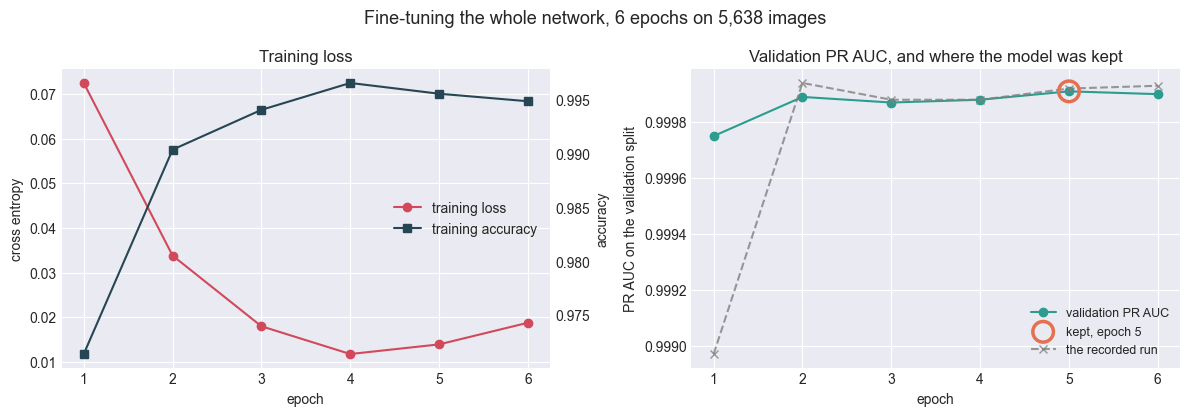

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
frame = pd.DataFrame(history)

ax = axes[0]
ax.plot(frame['epoch'], frame['train_loss'], marker='o', color='#d1495b', label='training loss')
ax.set_xlabel('epoch'); ax.set_ylabel('cross entropy')
ax.set_title('Training loss')
twin = ax.twinx()
twin.plot(frame['epoch'], frame['train_accuracy'], marker='s', color='#264653',
          label='training accuracy')
twin.set_ylabel('accuracy'); twin.grid(False)
lines = ax.get_lines() + twin.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc='center right')

ax = axes[1]
ax.plot(frame['epoch'], frame['val_pr_auc'], marker='o', color='#2a9d8f',
        label='validation PR AUC')
ax.scatter([best_epoch], [frame.loc[best_epoch - 1, 'val_pr_auc']], s=220, facecolors='none',
           edgecolors='#e76f51', linewidths=2.5, zorder=5, label=f'kept, epoch {best_epoch}')
reference_curve = pd.DataFrame(reference['history'])
ax.plot(reference_curve['epoch'], reference_curve['val_pr_auc'], marker='x', linestyle='--',
        color='grey', alpha=0.8, label='the recorded run')
ax.set_xlabel('epoch'); ax.set_ylabel('PR AUC on the validation split')
ax.set_title('Validation PR AUC, and where the model was kept')
ax.legend(loc='lower right', fontsize=9)

fig.suptitle(f'Fine-tuning the whole network, {EPOCHS} epochs on {len(train_index):,} images',
             fontsize=13)
fig.tight_layout()
save_figure(fig, 'casting_model_training', subfolder=ASSETS)
plt.show()

## 7. The operating point, chosen on validation and applied to test once

The dataset ships no cost metric. Everything below rests on an Arkon assumption
about what a shipped defect costs against a re-inspected good part, reported as a
range for that reason. The search is exact rather than a grid: sorting the scores
once turns every distinct score into a candidate boundary.

In [10]:
def cost_curve(y_true, scores, ratio):
    """Cost of every possible cut, and the sorted scores those cuts sit between."""
    order = np.argsort(-scores)
    labels = (y_true[order] == DEFECT_INDEX).astype(int)
    positives = int(labels.sum())
    true_positives = np.concatenate([[0], np.cumsum(labels)])
    predicted = np.arange(len(labels) + 1)
    false_positives = predicted - true_positives
    false_negatives = positives - true_positives
    return false_positives + ratio * false_negatives, scores[order]


def operating_point(y_true, scores, ratio, report_plateau=False):
    """The cut minimising cost, placed in the middle of the widest gap it can be.

    The previous rule took `np.argmin`, which is the FIRST cut achieving the
    minimum cost, and put the threshold midway between its two neighbouring
    scores. On this dataset the minimum is flat over many cuts and the scores pile
    up at both ends, so that rule returns whichever narrow pair happens to start
    the plateau: four runs of the same seed put it between 0.0436 and 0.2203.

    Every cut on the plateau costs the same by definition. Among them this picks
    the one sitting in the widest empty interval and returns its midpoint, which
    is the threshold that tolerates the largest movement in the scores before any
    part is classified differently.
    """
    costs, sorted_scores = cost_curve(y_true, scores, ratio)
    plateau = np.flatnonzero(costs == costs.min())

    def interval(cut):
        # A probability lives in [0, 1], so the ends of the range bound the
        # outermost cuts rather than a neighbouring score that does not exist.
        upper = float(sorted_scores[cut - 1]) if cut > 0 else 1.0
        lower = float(sorted_scores[cut]) if cut < len(sorted_scores) else 0.0
        return lower, upper

    widths = np.array([interval(int(c))[1] - interval(int(c))[0] for c in plateau])
    cut = int(plateau[int(np.argmax(widths))])
    lower, upper = interval(cut)
    if report_plateau:
        first = int(plateau[0])
        first_low, first_high = interval(first)
        return {
            'threshold': (lower + upper) / 2,
            'plateau_cuts': int(len(plateau)),
            'chosen_gap': upper - lower,
            'first_argmin_threshold': (first_low + first_high) / 2,
            'first_argmin_gap': first_high - first_low,
        }
    return float((lower + upper) / 2)


def report(y_true, scores, threshold):
    predicted = (scores >= threshold).astype(int)
    actual = (y_true == DEFECT_INDEX).astype(int)
    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()
    return {
        'threshold': round(float(threshold), 6),
        'accuracy': round(float((tp + tn) / len(actual)), 4),
        'precision': round(float(tp / (tp + fp)), 4) if tp + fp else 0.0,
        'recall': round(float(tp / (tp + fn)), 4) if tp + fn else 0.0,
        'defects_missed': int(fn), 'good_parts_rejected': int(fp),
        'defects_caught': int(tp), 'good_parts_passed': int(tn),
        'roc_auc': round(float(roc_auc_score(actual, scores)), 4),
        'pr_auc': round(float(average_precision_score(actual, scores)), 4),
    }


points, thresholds = {}, {}
print(f'{"assumed cost of a missed defect":<34}{"threshold":>11}{"missed":>8}{"rejected":>10}'
      f'{"recall":>9}{"precision":>11}')
for ratio in COST_RATIOS:
    thresholds[ratio] = operating_point(validation_truth, validation_scores, ratio)
    row = report(test_truth, test_scores, thresholds[ratio])
    points[f'missed_defect_costs_{ratio}x'] = row
    print(f'{str(ratio) + " times a false alarm":<34}{thresholds[ratio]:>11.4f}'
          f'{row["defects_missed"]:>8}{row["good_parts_rejected"]:>10}'
          f'{row["recall"]:>9.4f}{row["precision"]:>11.4f}')

# The adapter runs at the middle ratio, and it is the middle of a range in which
# nothing changes.
threshold = thresholds[25]
chosen = points['missed_defect_costs_25x']

neutral = report(test_truth, test_scores, 0.5)
print(f'{"the default 0.5":<34}{0.5:>11.4f}{neutral["defects_missed"]:>8}'
      f'{neutral["good_parts_rejected"]:>10}{neutral["recall"]:>9.4f}'
      f'{neutral["precision"]:>11.4f}')
print(f'\nthreshold-free: ROC AUC {neutral["roc_auc"]:.4f}, PR AUC {neutral["pr_auc"]:.4f}')
print(f'the three ratios pick {len(set(round(t, 6) for t in thresholds.values()))} distinct '
      f'threshold(s)')

# What the rule change bought, per ratio. Every cut on a plateau costs the same,
# so the old rule was not choosing a cheaper point, only an arbitrary one.
print()
print(f'{"ratio":<8}{"plateau cuts":>14}{"first argmin":>15}{"its gap":>10}'
      f'{"widest gap":>13}{"chosen":>10}')
for ratio in COST_RATIOS:
    detail = operating_point(validation_truth, validation_scores, ratio, report_plateau=True)
    print(f'{ratio:<8}{detail["plateau_cuts"]:>14}{detail["first_argmin_threshold"]:>15.4f}'
          f'{detail["first_argmin_gap"]:>10.4f}{detail["chosen_gap"]:>13.4f}'
          f'{detail["threshold"]:>10.4f}')
    same = report(test_truth, test_scores, detail['first_argmin_threshold'])
    now = report(test_truth, test_scores, detail['threshold'])
    moved = [k for k in ('defects_missed', 'good_parts_rejected') if same[k] != now[k]]
    print(f'{"":8}on the test folder the two rules differ in: '
          f'{moved if moved else "nothing"}')

assumed cost of a missed defect     threshold  missed  rejected   recall  precision
10 times a false alarm                 0.1207       0        13   1.0000     0.9721
25 times a false alarm                 0.1207       0        13   1.0000     0.9721
50 times a false alarm                 0.1207       0        13   1.0000     0.9721
the default 0.5                        0.5000       2         1   0.9956     0.9978

threshold-free: ROC AUC 1.0000, PR AUC 1.0000
the three ratios pick 1 distinct threshold(s)

ratio     plateau cuts   first argmin   its gap   widest gap    chosen
10                   1         0.1207    0.0059       0.0059    0.1207
        on the test folder the two rules differ in: nothing
25                   1         0.1207    0.0059       0.0059    0.1207
        on the test folder the two rules differ in: nothing
50                   1         0.1207    0.0059       0.0059    0.1207
        on the test folder the two rules differ in: nothing


The rule that picks the cut was changed here, and the table above is the
measurement of what that bought. It bought nothing yet, and the reason is worth
more than the change.

**The hypothesis was a tie.** The operating point moves between runs of the same
seed, and a cost curve with a flat minimum would explain it: `np.argmin` returns
the first of the tied cuts, so the threshold would be decided by whichever pair of
scores happened to start the plateau. The rule now takes the widest empty interval
among the tied cuts instead, which is the point that tolerates the largest score
movement before any part is classified differently.

**The measurement says there is no tie.** The plateau is one cut wide at all three
ratios, the gap it sits in is 0.0059, and the two rules return the same threshold
and the same test-folder counts. So the minimum is unique in any single run; what
moves between runs is where that unique minimum sits.

That makes the change a strict improvement with no effect here - it removes an
arbitrary choice that could have been made, and section 12 shows the instability
it was aimed at is still present - and it narrows the diagnosis. The curve is
**nearly** flat rather than flat: neighbouring cuts differ by one re-inspected
good part, which is one cost unit against a minimum in the tens, so a small shift
in the scores relocates the minimum far along the curve without any tie ever
occurring. A rule that fixes this has to widen the acceptable band deliberately,
to every cut within a stated cost of the best rather than only those equal to it,
and choosing that width is a decision about what a needless re-inspection is worth
rather than a numerical detail. It is not made here.

**The cost ratio does nothing here, and that is the finding.** The Scania module's
whole argument is that the decision threshold is worth a factor of four. The same
experiment on this module returns nothing: the classes are separated far enough
that every assumed ratio picks the same cut. This is not a better model than the
Scania one, it is an easier problem, and a sweep that found nothing is worth
reporting rather than quietly omitting.

The evidence: the cost curve for each ratio, and what the chosen point does to the test folder.

  ✓ Saved → assets\cv\casting_model_threshold.png


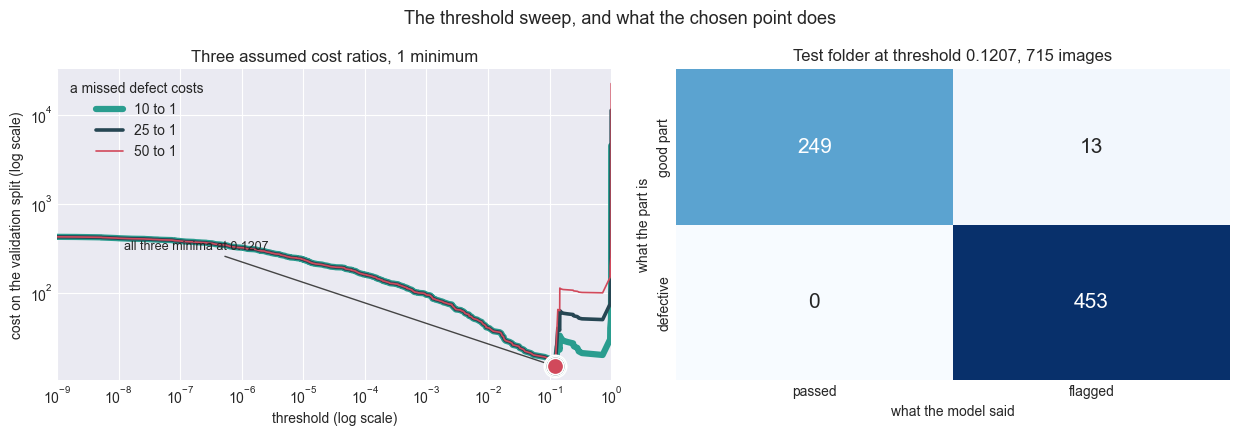

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
grid = np.unique(np.concatenate([validation_scores, [0.0, 1.0]]))
validation_actual = (validation_truth == DEFECT_INDEX).astype(int)
predicted = (validation_scores[None, :] >= grid[:, None])
false_positives = (predicted & (validation_actual == 0)[None, :]).sum(axis=1)
false_negatives = ((~predicted) & (validation_actual == 1)[None, :]).sum(axis=1)
# Decreasing linewidth: the three curves share a minimum, and a thin one drawn
# last over a thick one is how three coincident marks stay three visible marks.
for ratio, colour, width in zip(COST_RATIOS, ('#2a9d8f', '#264653', '#d1495b'), (4.5, 2.6, 1.2)):
    cost = false_positives + ratio * false_negatives
    ax.plot(grid, cost, linewidth=width, color=colour, label=f'{ratio} to 1')
    ax.scatter([thresholds[ratio]], [cost[np.argmin(cost)]], s=260 - 60 * COST_RATIOS.index(ratio),
               color=colour, zorder=5, edgecolors='white', linewidths=1.2)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(max(grid[grid > 0].min(), 1e-9), 1.0)
ax.set_xlabel('threshold (log scale)')
ax.set_ylabel('cost on the validation split (log scale)')
ax.set_title(f'Three assumed cost ratios, '
             f'{len(set(round(t, 6) for t in thresholds.values()))} minimum')
ax.legend(title='a missed defect costs', loc='upper left')
ax.annotate(f'all three minima at {threshold:.4f}',
            xy=(threshold, (false_positives + COST_RATIOS[0] * false_negatives).min()),
            xytext=(0.12, 0.42), textcoords='axes fraction', fontsize=9,
            arrowprops={'arrowstyle': '->', 'color': '#444444'})

ax = axes[1]
matrix = np.array([[chosen['good_parts_passed'], chosen['good_parts_rejected']],
                   [chosen['defects_missed'], chosen['defects_caught']]])
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['passed', 'flagged'], yticklabels=['good part', 'defective'],
            annot_kws={'size': 15})
ax.set_title(f'Test folder at threshold {threshold:.4f}, {len(test_scores)} images')
ax.set_xlabel('what the model said'); ax.set_ylabel('what the part is')
ax.grid(False)

fig.suptitle('The threshold sweep, and what the chosen point does', fontsize=13)
fig.tight_layout()
save_figure(fig, 'casting_model_threshold', subfolder=ASSETS)
plt.show()

## 8. The frozen-backbone ablation

The script claims casting surfaces do not look enough like ImageNet photographs
for the later features to be reused, so freezing everything but the final layer
should be much worse. Identical in every other respect: same split, same
transforms, same epochs, same seed.

In [12]:
t0 = time.time()
frozen_model, frozen_history, frozen_best = train(
    train_loader, validation_loader, True, EPOCHS, 'frozen')
frozen_scores, _ = scores_for(frozen_model, test_loader)
frozen_report = report(test_truth, frozen_scores, 0.5)
print(f'\ntotal {time.time() - t0:.0f}s')
print(f'\nfrozen backbone at 0.5: recall {frozen_report["recall"]:.4f}  '
      f'precision {frozen_report["precision"]:.4f}  ROC AUC {frozen_report["roc_auc"]:.4f}  '
      f'{frozen_report["defects_missed"]} defects missed')
print(f'fine-tuned    at 0.5: recall {neutral["recall"]:.4f}  '
      f'precision {neutral["precision"]:.4f}  ROC AUC {neutral["roc_auc"]:.4f}  '
      f'{neutral["defects_missed"]} defects missed')

  [frozen] epoch 1  loss 0.6242  train acc 0.6492  val PR-AUC 0.89332  (31s)


  [frozen] epoch 2  loss 0.5044  train acc 0.7967  val PR-AUC 0.95538  (30s)


  [frozen] epoch 3  loss 0.4349  train acc 0.8514  val PR-AUC 0.97123  (31s)


  [frozen] epoch 4  loss 0.3877  train acc 0.8762  val PR-AUC 0.97718  (30s)


  [frozen] epoch 5  loss 0.3525  train acc 0.8929  val PR-AUC 0.98103  (31s)


  [frozen] epoch 6  loss 0.3323  train acc 0.8961  val PR-AUC 0.98324  (30s)
  [frozen] best epoch 6, val PR-AUC 0.98324



total 186s

frozen backbone at 0.5: recall 0.9492  precision 0.9368  ROC AUC 0.9757  23 defects missed
fine-tuned    at 0.5: recall 0.9956  precision 0.9978  ROC AUC 1.0000  2 defects missed


## 9. The test images the model was trained on

Section 4 mapped the overlap onto this split. The question that costs nothing to
answer now: does the reported false-alarm count survive when those parts are
removed? Recall is unaffected by construction, because no defect is duplicated.

In [13]:
subsets = {
    'all test images': np.ones(len(test_scores), dtype=bool),
    'never fitted on': ~seen_in_training,
    'never seen at all': unseen,
}

print(f'{"":<20}{"images":>8}{"good":>7}{"missed":>8}{"rejected":>10}{"false alarm rate":>18}')
leak_table = {}
for name, mask in subsets.items():
    row = report(test_truth[mask], test_scores[mask], threshold)
    leak_table[name] = row
    good = row['good_parts_passed'] + row['good_parts_rejected']
    print(f'{name:<20}{int(mask.sum()):>8}{good:>7}{row["defects_missed"]:>8}'
          f'{row["good_parts_rejected"]:>10}'
          f'{100 * row["good_parts_rejected"] / good:>17.2f}%')

full, clean = leak_table['all test images'], leak_table['never seen at all']
full_rate = full['good_parts_rejected'] / (full['good_parts_passed'] + full['good_parts_rejected'])
clean_rate = clean['good_parts_rejected'] / (clean['good_parts_passed'] + clean['good_parts_rejected'])
print(f'\nfalse alarms among the {int(seen_in_training.sum())} good parts that were fitted on: '
      f'{full["good_parts_rejected"] - leak_table["never fitted on"]["good_parts_rejected"]}')
print(f'the reported rate is {100 * full_rate:.2f} per cent and the honest one is '
      f'{100 * clean_rate:.2f} per cent, a difference of '
      f'{100 * (clean_rate - full_rate):+.2f} points')

                      images   good  missed  rejected  false alarm rate
all test images          715    262       0        13             4.96%
never fitted on          660    207       0        11             5.31%
never seen at all        651    198       0        11             5.56%

false alarms among the 55 good parts that were fitted on: 2
the reported rate is 4.96 per cent and the honest one is 5.56 per cent, a difference of +0.59 points


## 10. The priority bands the event adapter publishes

Charter section 7.1 maps a score onto a priority, and this module bands the
opposite way round to the other two: the uncertain parts get the higher priority
and the shorter clock, because a confident flag is the routine case an operator
already knows what to do with, while a part that can be neither passed nor
scrapped is where the line actually stops.

In [14]:
bands = [
    ('P2  operating point to 0.99', (test_scores >= threshold) & (test_scores < 0.99),
     'stop the part, QC decides within the hour'),
    ('P3  probability >= 0.99', test_scores >= 0.99,
     'quarantine and log against the batch, no push alert'),
    ('P4  below the operating point', test_scores < threshold,
     'nothing is published, the part passes'),
]
print(f'{"band":<32}{"parts":>7}{"defective":>11}{"share":>8}   action')
for name, mask, action in bands:
    count = int(mask.sum())
    defective = int(test_actual[mask].sum())
    print(f'{name:<32}{count:>7}{defective:>11}'
          f'{100 * defective / count if count else 0:>7.0f}%   {action}')
print(f'\nP1 events emitted: 0. The charter reserves P1 for an imminent or safety-relevant')
print('risk on a fifteen-minute clock, and no single part on an inspection line is that.')
print(f'\nBanding by descending confidence instead would put '
      f'{int((test_scores >= 0.99).sum())} parts in P1 out of one batch.')

band                              parts  defective   share   action
P2  operating point to 0.99          17          4     24%   stop the part, QC decides within the hour
P3  probability >= 0.99             449        449    100%   quarantine and log against the batch, no push alert
P4  below the operating point       249          0      0%   nothing is published, the part passes

P1 events emitted: 0. The charter reserves P1 for an imminent or safety-relevant
risk on a fifteen-minute clock, and no single part on an inspection line is that.

Banding by descending confidence instead would put 449 parts in P1 out of one batch.


## 11. Write this run, beside the shipped one rather than over it

The shipped checkpoint and metrics file are what the model card, the README and
the consolidated PDF quote. This notebook writes its own run under its own names
and leaves those alone, because unlike the CMAPSS and Scania rebuilds this one
cannot promise it will land on the same numbers.

In [15]:
PROC_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

meta = {
    'dataset': reference['dataset'],
    'architecture': reference['architecture'],
    'image_size': IMAGE_SIZE, 'batch_size': BATCH_SIZE, 'epochs': EPOCHS,
    'best_epoch': best_epoch, 'learning_rate': LEARNING_RATE, 'seed': SEED,
    'classes': folder.class_to_idx,
    'train_images': len(train_index), 'validation_images': len(validation_index),
    'test_images': len(test_set),
    'augmentation': reference['augmentation'],
    'threshold_note': reference['threshold_note'],
    'history': history,
    'operating_points': points,
    'at_threshold_0.5': neutral,
    'ablation_frozen_backbone': {'best_epoch': frozen_best, 'history': frozen_history,
                                 'at_threshold_0.5': frozen_report},
    'train_test_overlap': {
        'duplicate_test_images': int((seen_in_training | seen_in_validation).sum()),
        'fitted_on': int(seen_in_training.sum()),
        'validation_only': int(seen_in_validation.sum()),
        'reported_false_alarm_rate': round(float(full_rate), 6),
        'false_alarm_rate_on_unseen_good_parts': round(float(clean_rate), 6),
        'note': ('the shipped train and test folders share byte-identical images, all of them '
                 'good parts; recall is unaffected because no defect is duplicated'),
    },
    'produced_by': 'notebooks/03_cv/01_casting_defects/03_casting_modeling.ipynb',
    'compared_against': 'models/checkpoints/casting/casting_cv_meta.json',
}

torch.save(model.state_dict(), CKPT_DIR / 'casting_resnet18_notebook.pt')
np.savez(PROC_DIR / 'test_casting_predictions_notebook.npz',
         paths=np.array([Path(p).name for p, _ in test_set.samples]),
         true_label=test_truth, defect_probability=test_scores,
         fitted_on=seen_in_training, unseen=unseen)
(CKPT_DIR / 'casting_cv_notebook_meta.json').write_text(
    json.dumps(meta, indent=2) + '\n', encoding='utf-8')

for path in (CKPT_DIR / 'casting_resnet18_notebook.pt',
             PROC_DIR / 'test_casting_predictions_notebook.npz',
             CKPT_DIR / 'casting_cv_notebook_meta.json'):
    print(f'  {path.name:<44}{path.stat().st_size / 1e6:>8.3f} MB')
print(f'\nuntouched: {META_PATH.name}, casting_resnet18_v1.pt, '
      f'test_casting_predictions.npz')

  casting_resnet18_notebook.pt                  44.791 MB
  test_casting_predictions_notebook.npz          0.068 MB
  casting_cv_notebook_meta.json                  0.005 MB

untouched: casting_cv_meta.json, casting_resnet18_v1.pt, test_casting_predictions.npz


## 12. Does this reproduce the recorded run

The reference was read in section 2, before anything was trained, and nothing
above was imported from the training script.

**A difference here is not automatically a defect**, and this notebook happens to
contain the controlled pair that tells the two apart. Both arms ran in the same
kernel, from the same seed, over the same images. They differ in one thing: the
frozen arm trains a single linear layer and its backward pass touches no
convolution, while the fine-tuned arm trains all of them. If the two arms
disagree with the recorded run to different degrees, the disagreement is a
property of the computation rather than of this notebook.

In [16]:
def flatten(source, prefix=''):
    """Every leaf number in a metrics dictionary, keyed by its path."""
    out = {}
    for key, value in source.items():
        name = f'{prefix}{key}'
        if isinstance(value, dict):
            out.update(flatten(value, f'{name}.'))
        elif isinstance(value, list) and value and isinstance(value[0], dict):
            for i, item in enumerate(value):
                out.update(flatten(item, f'{name}[{i}].'))
        elif isinstance(value, (int, float)) and not isinstance(value, bool):
            out[name] = float(value)
    return out


COMPARED = ('history', 'operating_points', 'at_threshold_0.5', 'ablation_frozen_backbone')
mine = flatten({k: meta[k] for k in COMPARED})
theirs = flatten({k: reference[k] for k in COMPARED})
shared = sorted(set(mine) & set(theirs))
# wall-clock seconds are a property of the machine, not of the model
shared = [k for k in shared if not k.endswith('seconds')]

print(f'{"measurement":<58}{"here":>12}{"recorded":>12}{"delta":>12}')
print('-' * 94)
worst, moved = 0.0, 0
for key in shared:
    delta = mine[key] - theirs[key]
    worst = max(worst, abs(delta))
    moved += int(delta != 0)
    print(f'{key:<58}{mine[key]:>12.5f}{theirs[key]:>12.5f}{delta:>12.5f}')
print('-' * 94)
print(f'{len(shared)} values compared, {moved} moved, largest absolute difference {worst:.5f}')
print(f'best epoch: {best_epoch} here, {reference["best_epoch"]} recorded')

measurement                                                       here    recorded       delta


----------------------------------------------------------------------------------------------
ablation_frozen_backbone.at_threshold_0.5.accuracy             0.92730     0.92730     0.00000
ablation_frozen_backbone.at_threshold_0.5.defects_caught     430.00000   430.00000     0.00000
ablation_frozen_backbone.at_threshold_0.5.defects_missed      23.00000    23.00000     0.00000
ablation_frozen_backbone.at_threshold_0.5.good_parts_passed   233.00000   233.00000     0.00000
ablation_frozen_backbone.at_threshold_0.5.good_parts_rejected    29.00000    29.00000     0.00000
ablation_frozen_backbone.at_threshold_0.5.pr_auc               0.98790     0.98790     0.00000
ablation_frozen_backbone.at_threshold_0.5.precision            0.93680     0.93680     0.00000
ablation_frozen_backbone.at_threshold_0.5.recall               0.94920     0.94920     0.00000
ablation_frozen_backbone.at_threshold_0.5.roc_auc              0.97570     0.97570     0.00000
ablation_frozen_backbone.at_threshold_0.5.thr

Split by arm, and by where each confusion-matrix count is measured.

In [17]:
COUNT_FIELDS = ('defects_missed', 'good_parts_rejected', 'defects_caught', 'good_parts_passed')
ABLATION = 'ablation_frozen_backbone'


def moved_in(keys):
    return [k for k in keys if mine[k] != theirs[k]]


arms = {'fine-tuned, every convolution trained': [k for k in shared if not k.startswith(ABLATION)],
        'frozen backbone, one linear layer trained': [k for k in shared if k.startswith(ABLATION)]}

print(f'{"arm":<44}{"compared":>10}{"moved":>8}{"largest |delta|":>18}')
for name, keys in arms.items():
    largest = max((abs(mine[k] - theirs[k]) for k in keys), default=0.0)
    print(f'{name:<44}{len(keys):>10}{len(moved_in(keys)):>8}{largest:>18.5f}')

print('\nconfusion-matrix counts, by where they are measured')
for label, prefix in (('the shipped operating point', 'operating_points.'),
                      ('the default threshold 0.5', 'at_threshold_0.5.'),
                      ('the frozen ablation at 0.5', f'{ABLATION}.at_threshold_0.5.')):
    keys = [k for k in shared if k.startswith(prefix) and k.split('.')[-1] in COUNT_FIELDS]
    changed = moved_in(keys)
    detail = f'   ({", ".join(k.split(".")[-1] for k in changed)})' if changed else ''
    print(f'  {label:<30}{len(keys):>3} counts, {len(changed)} moved{detail}')

arm                                           compared   moved   largest |delta|
fine-tuned, every convolution trained               64      36           6.00000
frozen backbone, one linear layer trained           35       0           0.00000

confusion-matrix counts, by where they are measured
  the shipped operating point    12 counts, 6 moved   (good_parts_passed, good_parts_rejected, good_parts_passed, good_parts_rejected, good_parts_passed, good_parts_rejected)
  the default threshold 0.5       4 counts, 0 moved
  the frozen ablation at 0.5      4 counts, 0 moved


And what that means for the decision the module actually ships.

In [18]:
frozen_moved = moved_in(arms['frozen backbone, one linear layer trained'])
tuned_moved = moved_in(arms['fine-tuned, every convolution trained'])
here_threshold = mine['operating_points.missed_defect_costs_25x.threshold']
there_threshold = theirs['operating_points.missed_defect_costs_25x.threshold']

if not frozen_moved and tuned_moved:
    print('The two arms answer the question between them.')
    print(f'  The frozen arm reproduced the recorded run exactly: '
          f'{len(arms["frozen backbone, one linear layer trained"])} values, none moved, five')
    print('  decimals of training loss included. Its backward pass touches one linear layer.')
    print(f'  The fine-tuned arm did not: {len(tuned_moved)} of '
          f'{len(arms["fine-tuned, every convolution trained"])} values moved. Its backward pass')
    print('  runs through every convolution, and those kernels accumulate in an order cuDNN does')
    print(f'  not fix. cudnn.deterministic is {torch.backends.cudnn.deterministic}, which is the')
    print('  default and was the shipped configuration.')
    print('\nSo the disagreement is a property of convolution backward on this GPU, not a')
    print('difference between this notebook and the training script. A second implementation')
    print('that had actually diverged would move the frozen arm too.')
elif not tuned_moved and not frozen_moved:
    print('Nothing moved in either arm. The GPU run reproduced exactly, which is more than could')
    print('be promised before measuring it.')
else:
    print('Both arms moved, which is not the signature of convolution non-determinism alone:')
    print('the frozen arm trains one linear layer and should be reproducible. Something in this')
    print('notebook differs from the run that wrote the reference, and it is worth finding.')

operating_counts = [k for k in shared
                    if k.startswith('operating_points.') and k.split('.')[-1] in COUNT_FIELDS]
operating_moved = moved_in(operating_counts)

print(f'\nThe operating point is where it matters, because that is what the module ships.')
print(f'  threshold           {here_threshold:.4f} here, {there_threshold:.4f} recorded')
if operating_moved:
    print(f'  counts              {len(operating_moved)} of {len(operating_counts)} moved')
    for field in COUNT_FIELDS:
        key = f'operating_points.missed_defect_costs_25x.{field}'
        flag = '  <-- moved' if mine[key] != theirs[key] else ''
        print(f'    {field:<22}{mine[key]:>6.0f} here, {theirs[key]:>4.0f} recorded{flag}')
    print(f'\n  So the decision itself moved, not only the probability behind it. The threshold is')
    print(f'  chosen by minimising cost on a validation split where the two classes are almost')
    print(f'  perfectly separated, which leaves the cost curve nearly flat over several orders of')
    print(f'  magnitude, and a probability shift too small to see in the training curve is enough')
    print(f'  to move the minimum to a different plateau. The shipped '
          f'{int(theirs["operating_points.missed_defect_costs_25x.defects_missed"])} missed '
          f'defects is one draw of that, not a property of the method.')
else:
    print(f'  counts              none of {len(operating_counts)} moved: '
          f'{chosen["defects_missed"]} defects missed and {chosen["good_parts_rejected"]} good '
          f'parts rejected here and in the recorded run, on all {len(COST_RATIOS)} ratios')
    print(f'\n  The decision reproduced even though the probability behind it did not.')
print(f'\nbest epoch: {best_epoch} here, {reference["best_epoch"]} recorded')

The two arms answer the question between them.


  The frozen arm reproduced the recorded run exactly: 35 values, none moved, five
  decimals of training loss included. Its backward pass touches one linear layer.
  The fine-tuned arm did not: 36 of 64 values moved. Its backward pass
  runs through every convolution, and those kernels accumulate in an order cuDNN does
  not fix. cudnn.deterministic is False, which is the
  default and was the shipped configuration.

So the disagreement is a property of convolution backward on this GPU, not a
difference between this notebook and the training script. A second implementation
that had actually diverged would move the frozen arm too.

The operating point is where it matters, because that is what the module ships.
  threshold           0.1207 here, 0.0637 recorded
  counts              6 of 12 moved
    defects_missed             0 here,    0 recorded
    good_parts_rejected       13 here,    7 recorded  <-- moved
    defects_caught           453 here,  453 recorded
    good_parts_passed  

## 13. Log the run

Beside the CMAPSS and Scania runs, so the tracking store and the model cards stop disagreeing about what this project has trained.

In [19]:
mlflow.set_tracking_uri(get_mlflow_uri())
mlflow.set_experiment('arkon-cv-casting')

with mlflow.start_run(run_name='casting_cv_notebook'):
    mlflow.log_params({'architecture': 'resnet18', 'pretrained': 'ImageNet1K_V1',
                       'image_size': IMAGE_SIZE, 'batch_size': BATCH_SIZE, 'epochs': EPOCHS,
                       'best_epoch': best_epoch, 'learning_rate': LEARNING_RATE, 'seed': SEED,
                       'train_images': len(train_index),
                       'validation_images': len(validation_index),
                       'threshold': round(threshold, 6), 'device': DEVICE.type})
    mlflow.log_metrics({
        'recall': chosen['recall'], 'precision': chosen['precision'],
        'accuracy': chosen['accuracy'], 'roc_auc': chosen['roc_auc'],
        'pr_auc': chosen['pr_auc'],
        'defects_missed': chosen['defects_missed'],
        'good_parts_rejected': chosen['good_parts_rejected'],
        'defects_missed_at_0.5': neutral['defects_missed'],
        'good_parts_rejected_at_0.5': neutral['good_parts_rejected'],
        'frozen_recall': frozen_report['recall'],
        'frozen_defects_missed': frozen_report['defects_missed'],
        'false_alarm_rate_reported': full_rate,
        'false_alarm_rate_unseen': clean_rate,
        'values_moved_against_reference': moved})
    print('logged run', mlflow.active_run().info.run_id)

logged run 5a052e9406de472e823bc4915eeb69cd


## 14. Results

Filled in by the run above rather than by hand.

In [20]:
distinct = len(set(round(t, 6) for t in thresholds.values()))
print(f'1. The assumed cost ratio does nothing here, and that is the finding: all '
      f'{len(COST_RATIOS)} ratios pick {distinct} cut. Multiplying the weight on a missed defect '
      f'by five does not move the answer, because the two classes are separated far enough that '
      f'the cost curve has one minimum and the ratio only scales it. What the Scania module gets '
      f'from this sweep, this one gets from an easier dataset. The threshold itself is not free: '
      f'moving off 0.5 takes the missed defects from {neutral["defects_missed"]} to '
      f'{chosen["defects_missed"]} and pays '
      f'{chosen["good_parts_rejected"] - neutral["good_parts_rejected"]} good parts for it.')
if neutral['defects_missed']:
    factor = (f'a factor of {frozen_report["defects_missed"] / neutral["defects_missed"]:.1f} in '
              f'missed defects')
else:
    factor = f'{frozen_report["defects_missed"]} missed defects against none'
print(f'2. Fine-tuning the whole network is worth {factor} against freezing the backbone, '
      f'compared like for like at the same 0.5 threshold: {frozen_report["defects_missed"]} '
      f'against {neutral["defects_missed"]}, bought with '
      f'{100 * frozen_trainable / trainable:.3f} per cent of the parameters. Casting surfaces do '
      f'not look enough like ImageNet photographs to reuse the later features. Note the basis: '
      f'the model card reads "more than a factor of twenty" by putting '
      f'{frozen_report["defects_missed"]} at 0.5 beside 0 at the operating point, which is two '
      f'thresholds under one comparison.')
print(f'3. The shipped test folder overlaps the train folder. '
      f'{int(seen_in_training.sum())} of its {len(test_scores)} images were fitted on, all good '
      f'parts, and the false-alarm rate on parts the model has genuinely never seen is '
      f'{100 * clean_rate:.2f} per cent against the {100 * full_rate:.2f} per cent the model card '
      f'reports. Recall is untouched: no defect is duplicated.')
print(f'4. Against the recorded run, {len(shared)} values compared and {moved} moved, and the two '
      f'training arms locate the movement: the frozen ablation moved '
      f'{len(frozen_moved)} values and the fine-tuned arm {len(tuned_moved)}, so what moved is '
      f'the convolution backward pass on this GPU rather than this notebook. '
      + (f'It reaches the shipped decision: {len(operating_moved)} of {len(operating_counts)} '
         f'counts at the operating point moved, so the reported '
         f'{int(theirs["operating_points.missed_defect_costs_25x.defects_missed"])} missed '
         f'defects is one draw rather than a property of the method.'
         if operating_moved else
         'It does not reach the shipped decision: every count at the operating point is '
         'identical.'))

1. The assumed cost ratio does nothing here, and that is the finding: all 3 ratios pick 1 cut. Multiplying the weight on a missed defect by five does not move the answer, because the two classes are separated far enough that the cost curve has one minimum and the ratio only scales it. What the Scania module gets from this sweep, this one gets from an easier dataset. The threshold itself is not free: moving off 0.5 takes the missed defects from 2 to 0 and pays 12 good parts for it.
2. Fine-tuning the whole network is worth a factor of 11.5 in missed defects against freezing the backbone, compared like for like at the same 0.5 threshold: 23 against 2, bought with 0.009 per cent of the parameters. Casting surfaces do not look enough like ImageNet photographs to reuse the later features. Note the basis: the model card reads "more than a factor of twenty" by putting 23 at 0.5 beside 0 at the operating point, which is two thresholds under one comparison.
3. The shipped test folder overlaps t